# Day 1 lab, Part C: model budgets

**Goal.** You can calculate the three budgets of a model (parameters,
operations, peak activation memory) and decide if the model fits a device.

**Deliverable.** The completed table "model and device" with a reason for each
result, and the Decision Log.

**Credits.** The method (three budgets, lighthouse models, fit check) adapts
material from "Machine Learning Systems" by Vijay Janapa Reddi and
contributors (mlsysbook.ai, CC BY-NC-SA 4.0), Volume I, chapters 2 and 6.
MobileNetV2 and ResNet-18 come from the library `torchvision` (BSD-3-Clause).
The profiler code and the small networks are new code of this course. Keep
this cell.

**Time.** Part C: 55 min. Board measurement: 10 min. This notebook: 35 min.
Table and Decision Log: 10 min.

**Places for your work.** Search for `TODO (student)`. The notebook has five
tasks. The solution is in `solutions/model_budgets.ipynb`.

## 0. Setup

Run this cell first. It prints the versions that you write in your report.

In [1]:
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch import fx
from torch.fx.passes.shape_prop import ShapeProp

print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("torch      ", torch.__version__)
print("torchvision", torchvision.__version__)
print("machine    ", platform.machine())

KB = 1024          # This course uses 1 KB = 1024 bytes.
MB = 1024 * KB
GB = 1024 * MB

python      3.10.12
numpy       2.2.6
torch       2.14.1+cpu
torchvision 0.29.1+cpu
machine     x86_64


## 1. The cost of one layer (10 min)

Part 2 of the lecture gave these formulas for a convolution layer:

- Output size: $H_{out} = \lfloor (H + 2P - K) / S \rfloor + 1$. The same
  formula gives $W_{out}$.
- Weights: $K^2 \cdot (C_{in} / \text{groups}) \cdot C_{out}$.
  A standard convolution has `groups = 1`. A depthwise convolution has
  `groups = C_in`.
- Parameters: weights $+$ $C_{out}$ biases.
- Operations: weights $\times H_{out} \times W_{out}$ multiply-accumulate
  operations (MACs).

**Task 1.** Write the function `conv_cost`. The next cell compares your
result with PyTorch.

In [2]:
def conv_cost(h, w, c_in, c_out, k, stride=1, padding=0, groups=1):
    '''Return (h_out, w_out, parameters, macs) of one convolution layer.'''
    h_out = (h + 2 * padding - k) // stride + 1
    w_out = (w + 2 * padding - k) // stride + 1
    weights = k * k * (c_in // groups) * c_out
    parameters = weights + c_out
    macs = weights * h_out * w_out
    return h_out, w_out, parameters, macs

In [3]:
def check_conv_cost():
    '''Compare conv_cost with a PyTorch layer for three layers.'''
    cases = [
        # (name, h, w, c_in, c_out, k, stride, padding, groups)
        ("standard, stride 2", 96, 96, 3, 16, 3, 2, 1, 1),
        ("depthwise", 48, 48, 16, 16, 3, 1, 1, 16),
        ("pointwise", 48, 48, 16, 32, 1, 1, 0, 1),
    ]
    all_correct = True
    for name, h, w, c_in, c_out, k, s, p, g in cases:
        layer = nn.Conv2d(c_in, c_out, k, stride=s, padding=p, groups=g)
        out = layer(torch.zeros(1, c_in, h, w))
        parameters = sum(t.numel() for t in layer.parameters())
        macs = layer.weight.numel() * out.shape[2] * out.shape[3]
        expected = (out.shape[2], out.shape[3], parameters, macs)
        yours = tuple(conv_cost(h, w, c_in, c_out, k, s, p, g))
        correct = yours == expected
        all_correct = all_correct and correct
        print(f"{name}: {'correct' if correct else 'NOT CORRECT'}")
        print(f"    expected {expected}")
        print(f"    yours    {yours}")
    print("Task 1:", "complete" if all_correct else "not complete")


check_conv_cost()

standard, stride 2: correct
    expected (48, 48, 448, 995328)
    yours    (48, 48, 448, 995328)
depthwise: correct
    expected (48, 48, 160, 331776)
    yours    (48, 48, 160, 331776)
pointwise: correct
    expected (48, 48, 544, 1179648)
    yours    (48, 48, 544, 1179648)
Task 1: complete


## 2. A profiler for a complete model (5 min)

The function `profile_model` does for a complete model what you did for one
layer. Read the rules. You do not change this code.

**Parameters.** The sum of all weights and biases.

**Operations.** The MACs of all convolution layers and all fully connected
layers.

**Peak activation memory.** The rule of the lecture:

- When a layer runs, its input and its output are in the RAM at the same time.
- A tensor stays in the RAM until its last use. A skip connection keeps a
  tensor for a longer time.
- Batch normalization and the activation function make no new tensor. The
  converter merges them into the layer before them.
- The peak is the largest sum of the tensors that are in the RAM at the same
  time. The unit is "values". Multiply by the bytes for each value.

This rule is for a runtime that keeps each tensor in a separate buffer. A real
runtime can need more or less. You measure the real value on Day 3.

In [4]:
# Layers that make no new tensor in a deployed model.
NO_NEW_TENSOR = (nn.BatchNorm2d, nn.ReLU, nn.ReLU6, nn.Dropout, nn.Identity,
                 nn.Flatten)


def profile_model(model, input_shape):
    '''Return the three budgets of a model and one row for each layer.

    input_shape is (channels, height, width) of one input, with no batch.
    '''
    model.eval()
    traced = fx.symbolic_trace(model)
    ShapeProp(traced).propagate(torch.zeros(1, *input_shape))
    modules = dict(traced.named_modules())

    layers = []      # one row for each tensor that the model makes
    tensor_of = {}   # graph node -> index of the row that holds its output
    for node in traced.graph.nodes:
        if node.op == "output":
            continue
        shape = tuple(node.meta["tensor_meta"].shape)[1:]
        module = modules.get(node.target) if node.op == "call_module" else None
        inputs = [tensor_of[n] for n in node.all_input_nodes]
        reshape_only = (
            (node.op == "call_function" and node.target is torch.flatten)
            or (node.op == "call_method"
                and node.target in ("flatten", "view", "reshape")))
        if isinstance(module, NO_NEW_TENSOR) or reshape_only:
            tensor_of[node] = inputs[0]   # the output uses the input buffer
            continue
        macs = 0
        if isinstance(module, nn.Conv2d):
            macs = module.weight.numel() * shape[1] * shape[2]
        elif isinstance(module, nn.Linear):
            macs = module.weight.numel()
        if node.op == "placeholder":
            kind = "input"
        elif module is not None:
            kind = type(module).__name__
        else:
            kind = getattr(node.target, "__name__", str(node.target))
        layers.append({"name": node.name, "kind": kind, "shape": shape,
                       "values": int(np.prod(shape)), "macs": macs,
                       "inputs": inputs})
        tensor_of[node] = len(layers) - 1

    # The last layer that reads each tensor.
    last_use = list(range(len(layers)))
    for index, layer in enumerate(layers):
        for tensor in layer["inputs"]:
            last_use[tensor] = max(last_use[tensor], index)

    # The tensors in the RAM while each layer runs.
    for index, layer in enumerate(layers):
        layer["in_ram"] = sum(layers[t]["values"] for t in range(index + 1)
                              if last_use[t] >= index)

    peak_layer = max(layers, key=lambda layer: layer["in_ram"])
    return {
        "parameters": sum(p.numel() for p in model.parameters()),
        "macs": sum(layer["macs"] for layer in layers),
        "peak_values": peak_layer["in_ram"],
        "peak_layer": peak_layer["name"],
        "layers": layers,
    }


def print_layers(profile, first=None):
    '''Print one row for each layer of a profile.'''
    print(f"{'layer':<21}{'type':<19}{'output (C, H, W)':<17}"
          f"{'values':>10}{'MACs':>12}{'in RAM':>11}")
    for layer in profile["layers"][:first]:
        print(f"{layer['name']:<21}{layer['kind']:<19}"
              f"{str(layer['shape']):<17}{layer['values']:>10,}"
              f"{layer['macs']:>12,}{layer['in_ram']:>11,}")

### Check the profiler with the example of the lecture

The example network of Part 2 of the lecture has three convolutions (16, 32, and 64 filters,
$3 \times 3$, stride 2, padding 1), global average pooling, and one fully
connected layer. The lecture gave 24 234 parameters, 6 304 384 MACs, and a
peak of 64 512 values.

In [5]:
class ExampleCNN(nn.Module):
    '''The example network of the lecture. Input 96 x 96 x 3, 10 classes.'''

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        return self.fc(self.flatten(self.pool(x)))


example = profile_model(ExampleCNN(), (3, 96, 96))
print_layers(example)
print()
print(f"parameters  {example['parameters']:>10,}   (lecture: 24,234)")
print(f"MACs        {example['macs']:>10,}   (lecture: 6,304,384)")
print(f"peak values {example['peak_values']:>10,}   (lecture: 64,512), "
      f"at layer {example['peak_layer']}")

layer                type               output (C, H, W)     values        MACs     in RAM
x                    input              (3, 96, 96)          27,648           0     27,648
conv1                Conv2d             (16, 48, 48)         36,864     995,328     64,512
conv2                Conv2d             (32, 24, 24)         18,432   2,654,208     55,296
conv3                Conv2d             (64, 12, 12)          9,216   2,654,208     27,648
pool                 AdaptiveAvgPool2d  (64, 1, 1)               64           0      9,280
fc                   Linear             (10,)                    10         640         74

parameters      24,234   (lecture: 24,234)
MACs         6,304,384   (lecture: 6,304,384)
peak values     64,512   (lecture: 64,512), at layer conv1


## 3. Three models: prediction before measurement (5 min)

You profile three models:

| Model | Input | Design |
|---|---|---|
| MobileNetV2 | $224 \times 224 \times 3$ | Inverted residual blocks, for phones |
| ResNet-18 | $224 \times 224 \times 3$ | Standard $3 \times 3$ convolutions with skip connections |
| Small depthwise CNN | $96 \times 96 \times 3$ | Three depthwise separable blocks, for a microcontroller |

The next cell defines the small depthwise CNN. The other two models come from
`torchvision`. The notebook needs no trained weights, so it downloads nothing.

In [6]:
def separable_block(c_in, c_out, stride):
    '''Depthwise 3 x 3 convolution, then pointwise 1 x 1 convolution.'''
    return nn.Sequential(
        nn.Conv2d(c_in, c_in, 3, stride=stride, padding=1, groups=c_in,
                  bias=False),
        nn.BatchNorm2d(c_in),
        nn.ReLU(),
        nn.Conv2d(c_in, c_out, 1, bias=False),
        nn.BatchNorm2d(c_out),
        nn.ReLU(),
    )


class SmallDepthwiseCNN(nn.Module):
    '''A small network for a microcontroller. Input 96 x 96 x 3.'''

    def __init__(self, classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
        )
        self.block1 = separable_block(16, 32, stride=1)
        self.block2 = separable_block(32, 64, stride=2)
        self.block3 = separable_block(64, 128, stride=2)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128, classes)

    def forward(self, x):
        x = self.block3(self.block2(self.block1(self.stem(x))))
        return self.fc(self.flatten(self.pool(x)))


MODELS = {
    "MobileNetV2": (torchvision.models.mobilenet_v2(weights=None),
                    (3, 224, 224)),
    "ResNet-18": (torchvision.models.resnet18(weights=None), (3, 224, 224)),
    "Small depthwise CNN": (SmallDepthwiseCNN(), (3, 96, 96)),
}
print("models:", ", ".join(MODELS))

models: MobileNetV2, ResNet-18, Small depthwise CNN


**Task 2.** Write your predictions **before** you run section 4. Use the
model names of the table above. The prediction is part of the assessment. A
wrong prediction costs no points. A missing prediction does.

In [7]:
# One possible prediction. Many students expect that the model with the most
# parameters also has the largest peak. Section 4 shows that this is wrong.
prediction = {
    "most parameters": "ResNet-18",
    "most operations (MACs)": "ResNet-18",
    "largest peak activation memory": "ResNet-18",
    "ratio of parameters, ResNet-18 to MobileNetV2": "about 3",
}
for question, answer in prediction.items():
    print(f"{question:<48} {answer}")

most parameters                                  ResNet-18
most operations (MACs)                           ResNet-18
largest peak activation memory                   ResNet-18
ratio of parameters, ResNet-18 to MobileNetV2    about 3


## 4. Profile the three models (5 min)

Run the cells. Compare the results with your predictions. Write one sentence
for each prediction that was wrong.

In [8]:
PROFILES = {name: profile_model(model, shape)
            for name, (model, shape) in MODELS.items()}

print(f"{'model':<20}{'parameters':>11}{'MACs':>15}{'peak values':>13}"
      f"  peak at layer")
for name, profile in PROFILES.items():
    print(f"{name:<20}{profile['parameters']:>11,}{profile['macs']:>15,}"
          f"{profile['peak_values']:>13,}  {profile['peak_layer']}")

model                parameters           MACs  peak values  peak at layer
MobileNetV2           3,504,872    300,774,272    1,505,280  features_2_conv_1_0
ResNet-18            11,689,512  1,814,073,344    1,003,520  maxpool
Small depthwise CNN      14,186      5,116,160      110,592  block1_3


The model size and the peak activation memory in bytes depend on the data
type: 4 bytes for `float32`, 1 byte for `int8`.

In [9]:
BYTES = {"float32": 4, "int8": 1}


def size_text(number_of_bytes):
    '''Return a size as text in KB or MB (1 KB = 1024 bytes).'''
    if number_of_bytes >= GB:
        return f"{number_of_bytes / GB:.1f} GB"
    if number_of_bytes >= MB:
        return f"{number_of_bytes / MB:.1f} MB"
    return f"{number_of_bytes / KB:.1f} KB"


print(f"{'model':<22}{'type':<9}{'model size':>12}{'peak in RAM':>13}")
for name, profile in PROFILES.items():
    for dtype, width in BYTES.items():
        print(f"{name:<22}{dtype:<9}"
              f"{size_text(profile['parameters'] * width):>12}"
              f"{size_text(profile['peak_values'] * width):>13}")

model                 type       model size  peak in RAM
MobileNetV2           float32       13.4 MB       5.7 MB
MobileNetV2           int8           3.3 MB       1.4 MB
ResNet-18             float32       44.6 MB       3.8 MB
ResNet-18             int8          11.1 MB     980.0 KB
Small depthwise CNN   float32       55.4 KB     432.0 KB
Small depthwise CNN   int8          13.9 KB     108.0 KB


The plot shows the tensors in the RAM while each layer runs. Find the layer
with the peak. Is it at the start or at the end of the model?

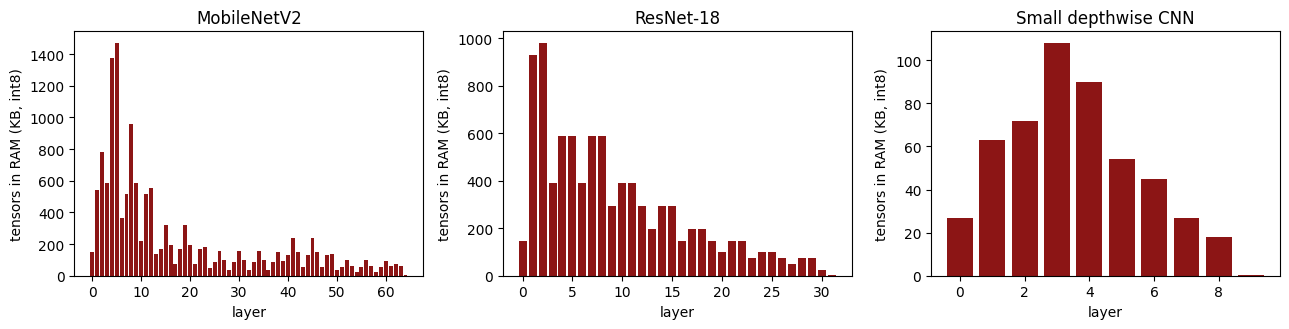

The first layers of MobileNetV2:
layer                type               output (C, H, W)     values        MACs     in RAM
x                    input              (3, 224, 224)       150,528           0    150,528
features_0_0         Conv2d             (32, 112, 112)      401,408  10,838,016    551,936
features_1_conv_0_0  Conv2d             (32, 112, 112)      401,408   3,612,672    802,816
features_1_conv_1    Conv2d             (16, 112, 112)      200,704   6,422,528    602,112
features_2_conv_0_0  Conv2d             (96, 112, 112)    1,204,224  19,267,584  1,404,928
features_2_conv_1_0  Conv2d             (96, 56, 56)        301,056   2,709,504  1,505,280
features_2_conv_2    Conv2d             (24, 56, 56)         75,264   7,225,344    376,320
features_3_conv_0_0  Conv2d             (144, 56, 56)       451,584  10,838,016    526,848


In [10]:
figure, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for axis, (name, profile) in zip(axes, PROFILES.items()):
    in_ram = [layer["in_ram"] / KB for layer in profile["layers"]]
    axis.bar(range(len(in_ram)), in_ram, color="#8c1515")
    axis.set_title(name)
    axis.set_xlabel("layer")
    axis.set_ylabel("tensors in RAM (KB, int8)")
figure.tight_layout()
plt.show()

print("The first layers of MobileNetV2:")
print_layers(PROFILES["MobileNetV2"], first=8)

## 5. Does the model fit the device? (10 min)

The table below gives the budgets of four devices. Each number has a source.

**Task 3.** Replace the two RAM values of the XIAO with the values that you
measured with the sketch `memory_report`:

- XIAO with no PSRAM: the value "Largest block that malloc can give".
- XIAO with PSRAM: the value "Free PSRAM".

If your group has no measured values, keep the values below and write this in
your report.

In [11]:
DEVICES = {
    # name: storage bytes for the model and the program (the flash of a
    # microcontroller), and RAM bytes for the tensors
    "Microcontroller, 256 KB": {
        # nRF52840: 1 MB of flash, 256 KB of RAM. A sensor sketch of the
        # course uses 45 944 bytes of RAM (result of the compiler).
        "flash": 1 * MB,
        "ram": 256 * KB - 45_944,
    },
    "XIAO, no PSRAM": {
        # The build output of the sketch memory_report with no PSRAM:
        # "Maximum is 3342336 bytes" for the sketch, and
        # "leaving 305848 bytes for local variables".
        "flash": 3_342_336,
        # The solution keeps the value of the compiler. Nobody measured the
        # "Largest block" on a board when this solution was written.
        "ram": 305_848,
    },
    "XIAO, with PSRAM": {
        "flash": 3_342_336,
        # The solution keeps the size of the PSRAM chip. Nobody measured the
        # "Free PSRAM" on a board when this solution was written.
        "ram": 8 * MB,
    },
    "Raspberry Pi 5": {
        # 64 GB microSD card and 8 GB of RAM. The operating system uses a
        # part of the two. You measure it on Day 7.
        "flash": 64 * GB,
        "ram": 8 * GB,
    },
}
for name, device in DEVICES.items():
    print(f"{name:<26} storage {size_text(device['flash']):>9}   "
          f"RAM for tensors {size_text(device['ram']):>9}")

Microcontroller, 256 KB    storage    1.0 MB   RAM for tensors  211.1 KB
XIAO, no PSRAM             storage    3.2 MB   RAM for tensors  298.7 KB
XIAO, with PSRAM           storage    3.2 MB   RAM for tensors    8.0 MB
Raspberry Pi 5             storage   64.0 GB   RAM for tensors    8.0 GB


**Task 4.** Write the function `fits`. It returns the result and the reason:

- `("fits", "")` when the model size is not larger than the flash **and** the
  peak activation memory is not larger than the RAM.
- `("does not fit", "flash")`, `("does not fit", "RAM")`, or
  `("does not fit", "flash and RAM")` in the other cases.

The program also needs flash. The sketches of Part B used about 300 KB. Use
the constant `PROGRAM_FLASH` for this.

In [12]:
PROGRAM_FLASH = 300 * KB   # flash for the program with no model


def fits(model_bytes, peak_bytes, device):
    '''Return (result, reason) for one model on one device.'''
    flash_ok = model_bytes + PROGRAM_FLASH <= device["flash"]
    ram_ok = peak_bytes <= device["ram"]
    if flash_ok and ram_ok:
        return "fits", ""
    if not flash_ok and not ram_ok:
        return "does not fit", "flash and RAM"
    return "does not fit", "RAM" if flash_ok else "flash"

The next cell makes the table of the deliverable: six rows (three models, two
data types) and four devices.

In [13]:
def result_table():
    '''Return the rows of the table: one row for each model and data type.'''
    rows = []
    for name, profile in PROFILES.items():
        for dtype, width in BYTES.items():
            model_bytes = profile["parameters"] * width
            peak_bytes = profile["peak_values"] * width
            cells = []
            for device in DEVICES.values():
                result, reason = fits(model_bytes, peak_bytes, device)
                cells.append(f"{result} ({reason})" if reason else result)
            rows.append((name, dtype, model_bytes, peak_bytes, cells))
    return rows


TABLE = result_table()
for device_index, device_name in enumerate(DEVICES):
    print(f"\n=== {device_name} ===")
    for name, dtype, model_bytes, peak_bytes, cells in TABLE:
        print(f"{name:<20}{dtype:<8}model {size_text(model_bytes):>8}  "
              f"peak {size_text(peak_bytes):>8}  {cells[device_index]}")


=== Microcontroller, 256 KB ===
MobileNetV2         float32 model  13.4 MB  peak   5.7 MB  does not fit (flash and RAM)
MobileNetV2         int8    model   3.3 MB  peak   1.4 MB  does not fit (flash and RAM)
ResNet-18           float32 model  44.6 MB  peak   3.8 MB  does not fit (flash and RAM)
ResNet-18           int8    model  11.1 MB  peak 980.0 KB  does not fit (flash and RAM)
Small depthwise CNN float32 model  55.4 KB  peak 432.0 KB  does not fit (RAM)
Small depthwise CNN int8    model  13.9 KB  peak 108.0 KB  fits

=== XIAO, no PSRAM ===
MobileNetV2         float32 model  13.4 MB  peak   5.7 MB  does not fit (flash and RAM)
MobileNetV2         int8    model   3.3 MB  peak   1.4 MB  does not fit (flash and RAM)
ResNet-18           float32 model  44.6 MB  peak   3.8 MB  does not fit (flash and RAM)
ResNet-18           int8    model  11.1 MB  peak 980.0 KB  does not fit (flash and RAM)
Small depthwise CNN float32 model  55.4 KB  peak 432.0 KB  does not fit (RAM)
Small depthwise CNN

### Questions about the table

Answer in your report. One or two sentences for each question.

1. Which model fits the microcontroller with 256 KB of RAM, and in which data
   type?
2. MobileNetV2 in `int8` has a peak of about 1.4 MB. The XIAO with PSRAM has
   8 MB of RAM. Why does the model not fit? Which number must change?
3. ResNet-18 has three times more parameters than MobileNetV2. Which model
   has the larger peak activation memory? Explain with the plot of section 4.
4. Which device can run all six rows? What is the price in power? Compare
   the rows "Edge" and "TinyML" of the paradigm table of Part 1 of the lecture.

### Answers

1. Only the small depthwise CNN in `int8`. Its peak is 108.0 KB and the
   device has 211.1 KB for tensors. In `float32` the peak is 432.0 KB, so the
   RAM is too small. The model size (13.9 KB or 55.4 KB) is not the problem.
2. The flash decides, not the RAM. The model has 3 504 872 bytes. The default
   partition of the board gives 3 342 336 bytes to one sketch, and the program
   needs about 300 KB of it. The number of parameters must decrease, for
   example with a narrower MobileNetV2. A different partition scheme of the
   8 MB flash chip is a second option. Nobody tested that option for this
   course.
3. MobileNetV2: 1 505 280 values. ResNet-18: 1 003 520 values. The second
   block of MobileNetV2 expands the tensor to 96 channels at
   $112 \times 112$ (1 204 224 values). ResNet-18 has its peak at the first
   pooling layer, and its later tensors are small. The parameters do not show
   the peak.
4. The Raspberry Pi 5 runs all six rows. The row "Edge" of the table gives
   15 to 40 W. The row "TinyML" gives 100 mW. The factor is 150 to 400. You
   measure the power of the two boards on Day 9.

## 6. Decision Log (10 min)

**Task 5.** Write about 100 words. State one design decision, give your
numbers, and name the trade-off.

Question of this lab: *You must classify images of $96 \times 96$ pixels on
the XIAOML Kit. Which of the three models do you select, in which data type,
and with PSRAM or with no PSRAM? Which budget decides?*

> Example of a Decision Log. We select the small depthwise CNN in `int8` on
> the XIAO with no PSRAM. Its model size is 13.9 KB and its peak activation
> memory is 108.0 KB. The budget of the board is 3.2 MB of flash and 298.7 KB
> of RAM, so the RAM budget decides, and the model uses about one third of
> it. In `float32` the peak is 432.0 KB, which does not fit with no PSRAM.
> MobileNetV2 in `int8` needs 3.3 MB of flash and 1.4 MB of RAM. It does not
> fit the flash, and it needs the PSRAM. The trade-off: the small model has
> less capacity, so its accuracy is lower, but it leaves the PSRAM free for
> the camera image. We measure the accuracy and the latency on Day 5.

## 7. Hand in

1. Copy the table of section 5 and your answers to the four questions into
   `report.md`.
2. Copy your predictions of section 3 and your Decision Log into `report.md`.
3. Show the notebook and the report to the instructor.